X_train → mostly normal data

X_val, y_val → validation with anomalies

X_test, y_test → final evaluation



**assumption**
row order can reasonably be interpreted as an implicit temporal ordering

Questions we want to answer
What are the 11 server variables and their basic distributions?
Are there missing, constant, or obviously problematic values?
How different are the feature scales?
Are features correlated/redundant?
Does the data exhibit meaningful temporal structure?
How are anomalies distributed in the validation set?
Do anomalous observations appear to have different feature behavior?
Is there evidence that motivates scaling, dimensionality reduction, temporal windows, and sequence models?

**Importantly, don't use the test set for exploratory decisions. Treat it as completely held out.**

## Load data

In [1]:
# LOAD DAAT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_train = np.load(
    "/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_part2.npy"
)

X_val = np.load(
    "/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_val_part2.npy"
)

y_val = np.load(
    "/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/y_val_part2.npy"
)

In [2]:
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")

X_train: (1000, 11)
X_val:   (100, 11)
y_val:   (100,)


In [3]:
n_features = X_train.shape[1]

print(f"Number of features: {n_features}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Number of features: 11
Training samples: 1000
Validation samples: 100


## Feature engineer

In [4]:
feature_names = [f"feature_{i+1}" for i in range(X_train.shape[1])] # if i have a name better
feature_names # dont invcenyed

['feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11']

In [5]:
train_df = pd.DataFrame(X_train, columns=feature_names)
val_df = pd.DataFrame(X_val, columns=feature_names)

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,1000.0,4.939400,7.812549,-17.488978,-0.316875,5.307967,9.988519,28.384866
feature_2,1000.0,-9.637268,7.297875,-38.593613,-14.748531,-9.713506,-4.861675,13.689702
feature_3,1000.0,13.814707,7.653368,-9.913776,8.574329,13.683700,18.648459,43.322411
feature_4,1000.0,-10.464489,9.180867,-35.968341,-16.857135,-10.443133,-4.187347,16.082439
feature_5,1000.0,-7.956229,8.082940,-35.351822,-13.441359,-8.031732,-2.511060,15.592370
feature_6,1000.0,10.199504,9.469136,-19.691088,3.845608,10.125638,16.528072,47.131732
feature_7,1000.0,-6.019408,7.462519,-32.280955,-10.927054,-6.140154,-0.396653,25.473844
feature_8,1000.0,7.969829,9.340749,-23.218312,1.903339,8.256812,14.180604,41.978198
feature_9,1000.0,-6.253182,5.446001,-22.039903,-10.088911,-6.277626,-2.540369,12.090256
feature_10,1000.0,2.324513,8.417604,-23.459247,-3.480037,2.549715,7.779696,26.166271


We can see:

- mean
- standard deviation
- min/max
- quartiles
- potential extreme values

The training distribution is the reference distribution for learning normal behavior.

## Data Quality

In [6]:
# Missing values
train_df.isna().sum()

feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
dtype: int64

In [7]:
print("Train missing values:", np.isnan(X_train).sum())
print("Validation missing values:", np.isnan(X_val).sum())

Train missing values: 0
Validation missing values: 0


In [8]:
# Constant near constant features
train_df.nunique().sort_values()
#.....analyze this

feature_1     1000
feature_2     1000
feature_3     1000
feature_4     1000
feature_5     1000
feature_6     1000
feature_7     1000
feature_8     1000
feature_9     1000
feature_10    1000
feature_11    1000
dtype: int64

In [9]:
zero_variance = train_df.columns[train_df.var() == 0]

print("Zero-variance features:")
print(list(zero_variance))

Zero-variance features:
[]


### analyze this......

## Feature distributions

We are looking for:

very different scales
skewness
heavy tails
multimodality
suspicious extreme values
features that may benefit from transformation


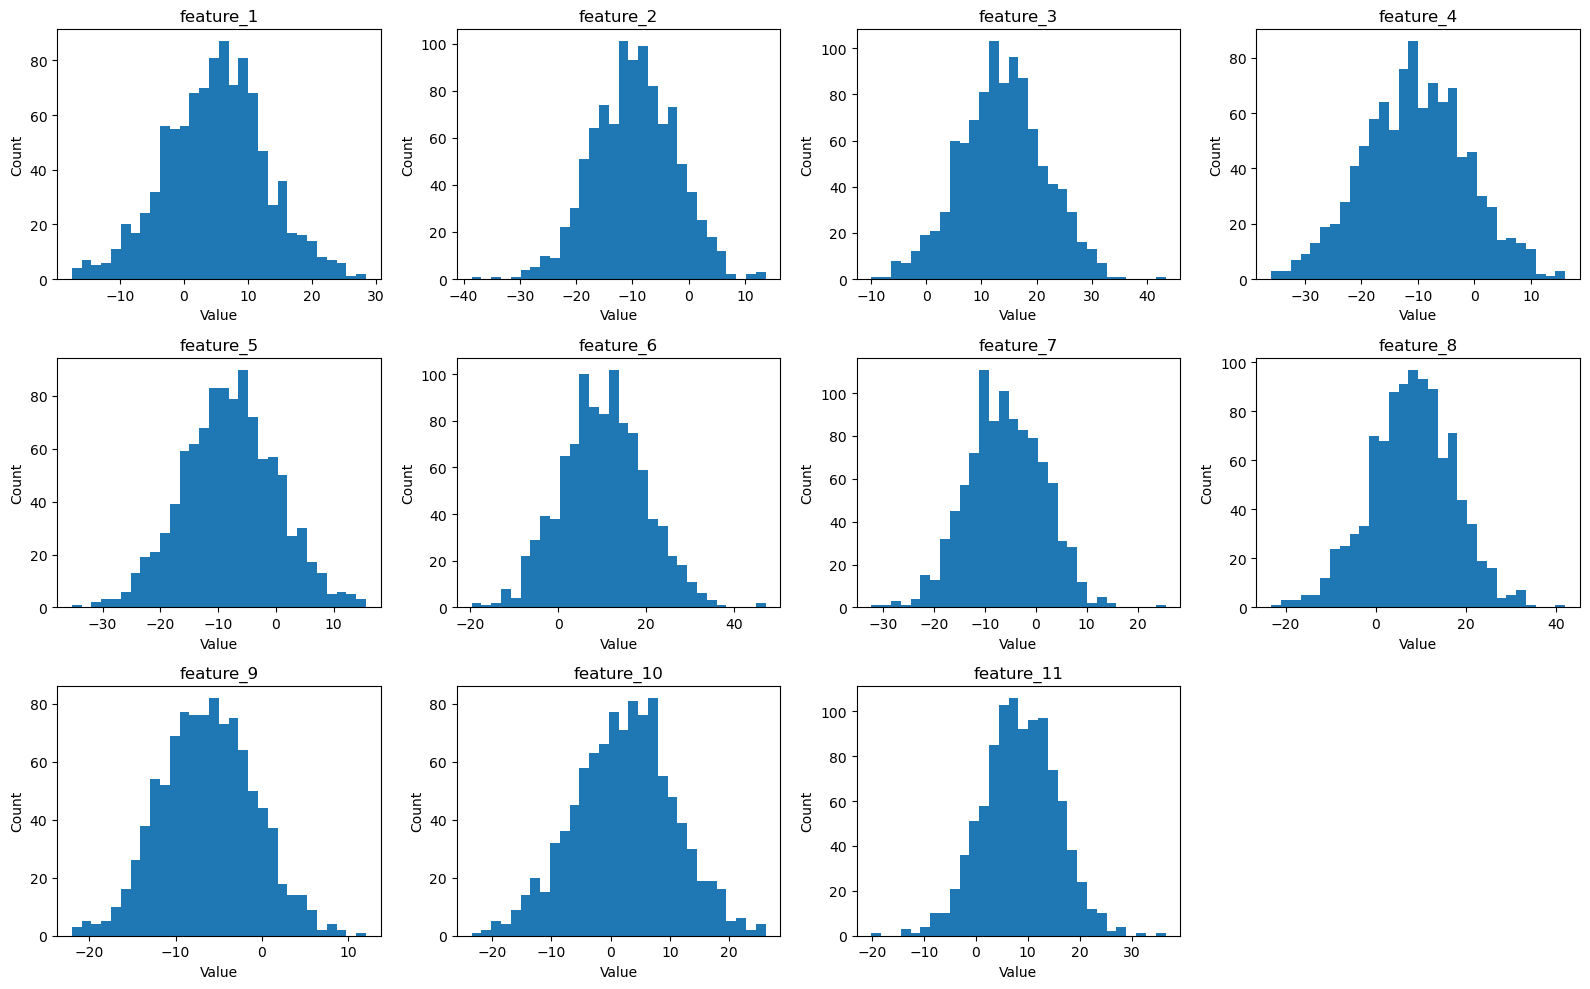

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, feature in zip(axes.flat, feature_names):
    ax.hist(train_df[feature], bins=30)
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

for ax in axes.flat[len(feature_names):]:
    ax.remove()

plt.tight_layout()

**Note** this is anomaly detection, an extreme value isn't automatically a bad data point. It may be precisely the kind of behavior the model needs to identify.

.....................analyze!!!!!!



## Feature scale comparisson

If the features have substantially different scales, that's a strong practical motivation for the preprocessing/scaling stage.

You don't need to conclude "therefore StandardScaler is definitely correct." Rather:

The features exhibit different numerical scales, motivating feature scaling as part of preprocessing. The appropriate scaler is subsequently treated as a configurable preprocessing choice.

In [11]:
stats = train_df.agg(["mean", "std", "min", "max"]).T
stats

,mean,std,min,max
feature_1,4.939400,7.812549,-17.488978,28.384866
feature_2,-9.637268,7.297875,-38.593613,13.689702
feature_3,13.814707,7.653368,-9.913776,43.322411
feature_4,-10.464489,9.180867,-35.968341,16.082439
feature_5,-7.956229,8.082940,-35.351822,15.592370
feature_6,10.199504,9.469136,-19.691088,47.131732
feature_7,-6.019408,7.462519,-32.280955,25.473844
feature_8,7.969829,9.340749,-23.218312,41.978198
feature_9,-6.253182,5.446001,-22.039903,12.090256
feature_10,2.324513,8.417604,-23.459247,26.166271


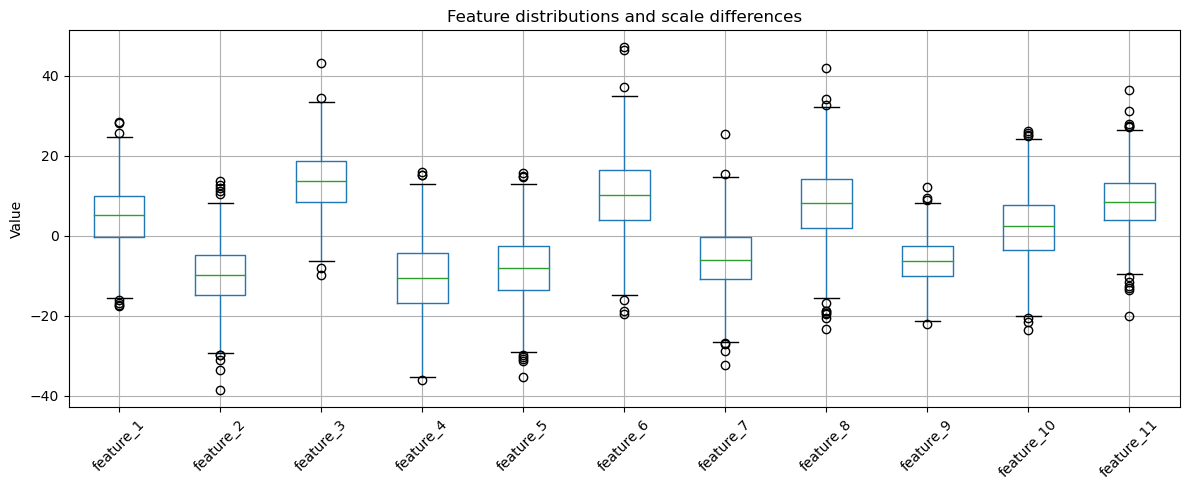

In [12]:
plt.figure(figsize=(12, 5))
train_df.boxplot()
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.title("Feature distributions and scale differences")
plt.tight_layout()

## Correlation analysis

What you're looking for:

strongly correlated variables
potentially redundant features
groups of related server measurements

This can motivate experimenting with PCA, but don't say PCA is necessary just because correlations exist.

For example:

Several features exhibit correlation, indicating that the measurements are not independent. This motivates considering dimensionality-reduction techniques such as PCA as an optional preprocessing component.



**note** -> see if corr gives LINEAR corr

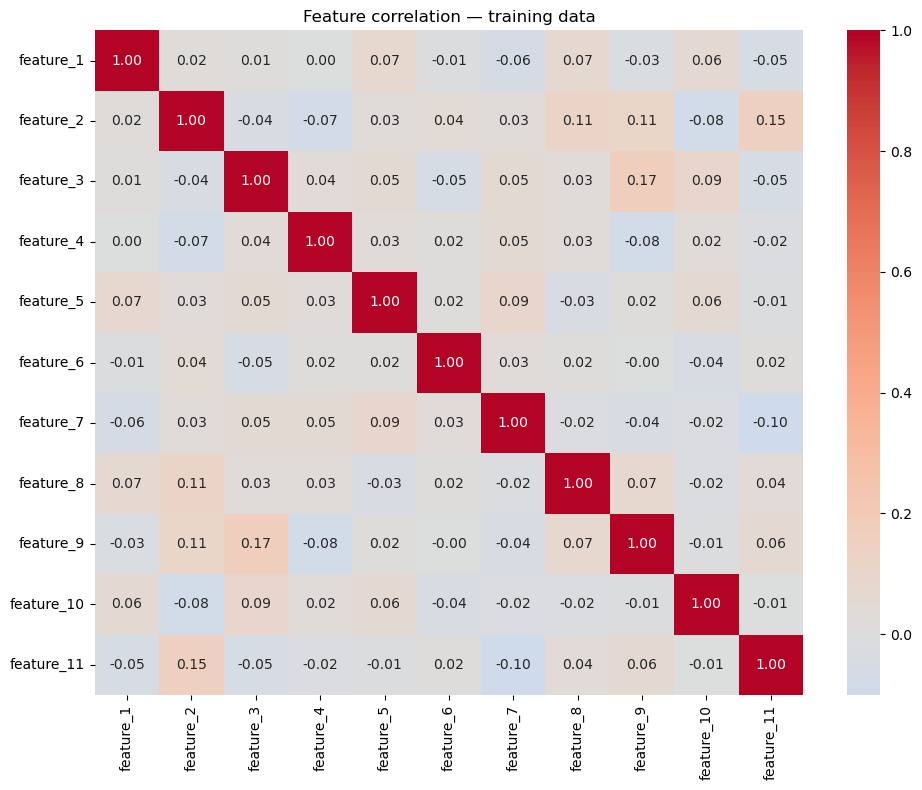

In [13]:
corr = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature correlation — training data")
plt.tight_layout()

## Temporal strucure

You don't actually need a real timestamp column to explore whether row ordering contains useful structure.

State explicitly:

The dataset does not provide an explicit timestamp in this experiment. Nevertheless, observations are assumed to be ordered according to their acquisition sequence, giving the dataset an implicit temporal index.

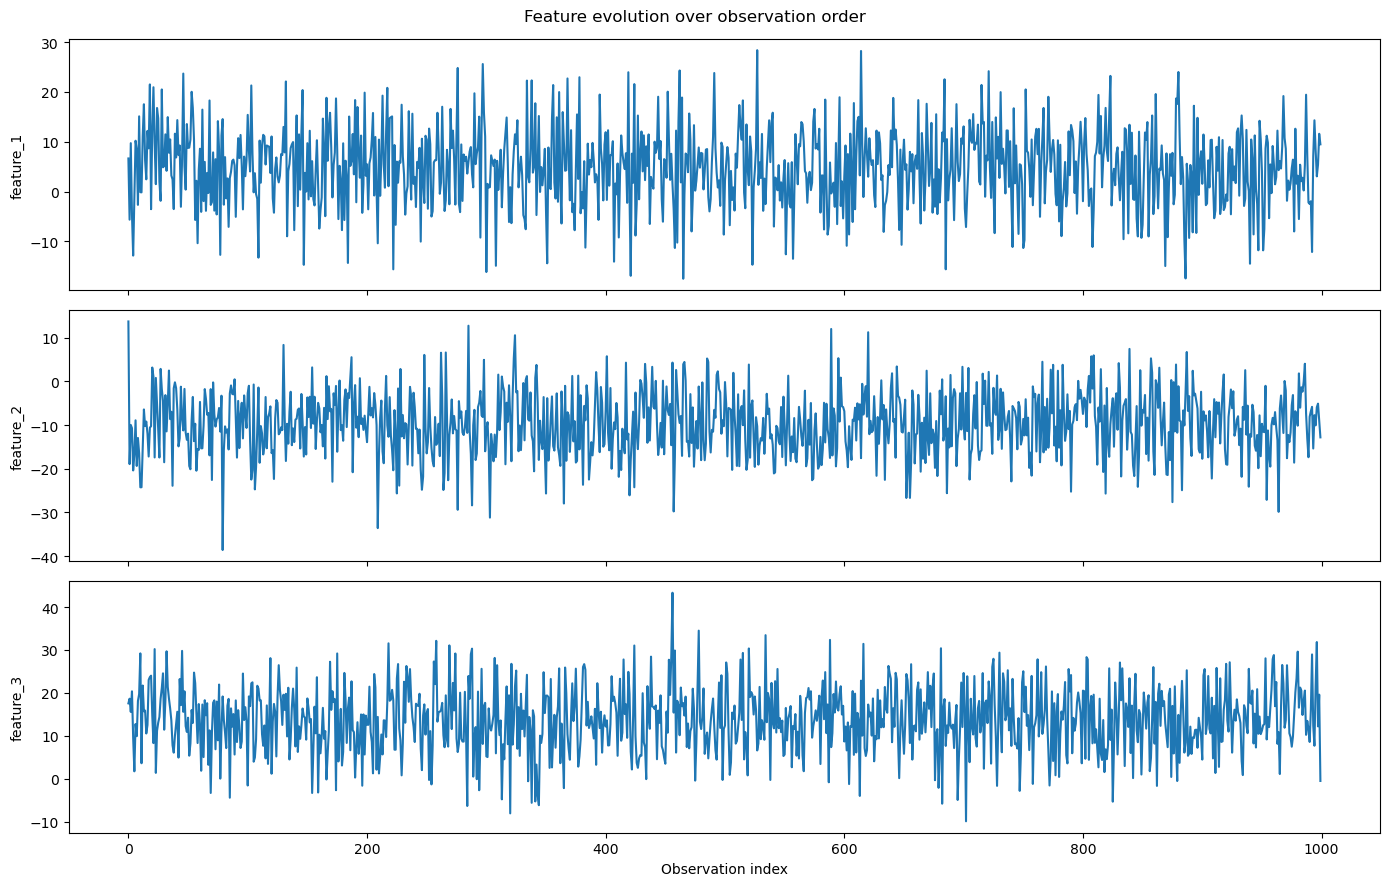

In [14]:
time = np.arange(len(X_train))

# plot a few representative features
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, feature in zip(axes, feature_names[:3]):
    ax.plot(time, train_df[feature])
    ax.set_ylabel(feature)

axes[-1].set_xlabel("Observation index")
fig.suptitle("Feature evolution over observation order")
plt.tight_layout()


int the plot we are looking for:You're looking for:

trends
periodicity
local changes
bursts
regime changes
obvious serial dependence

## Auitorcorrelation/temporal dependence

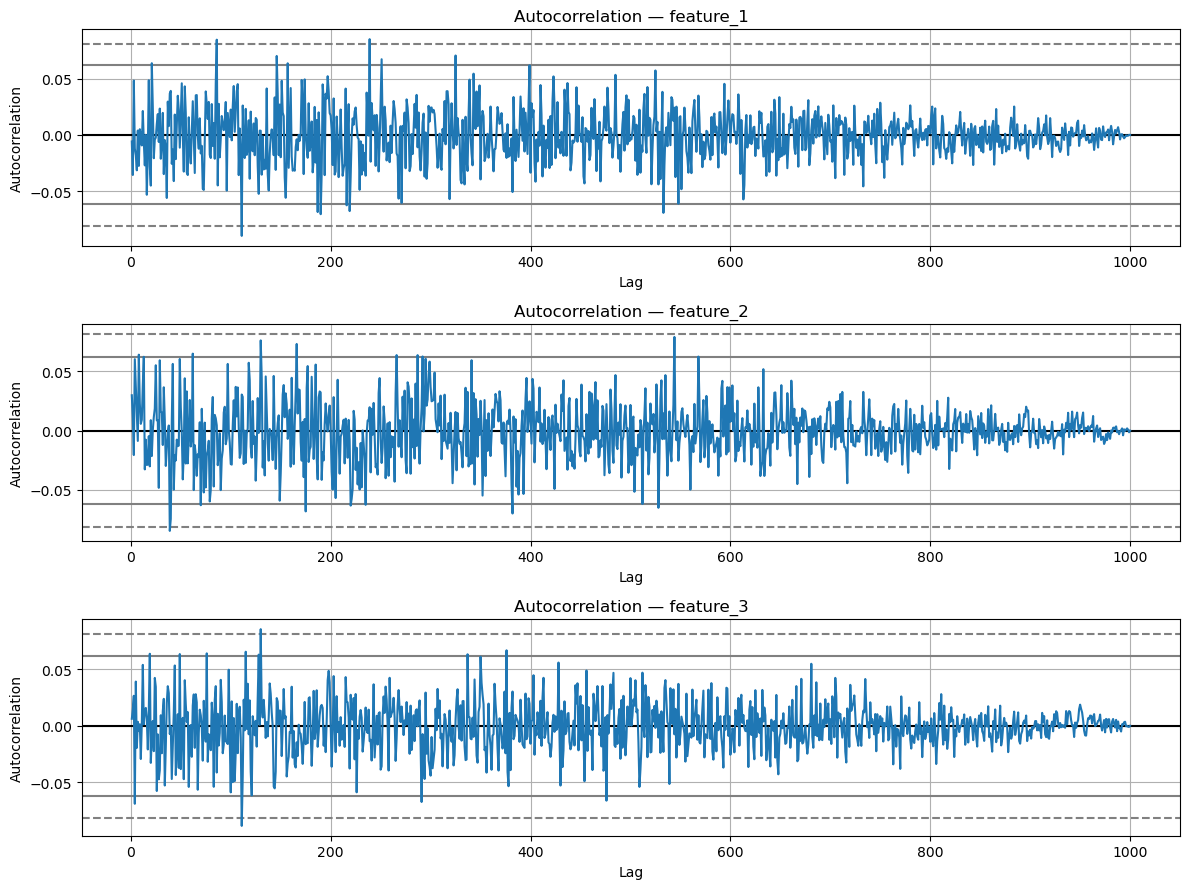

In [15]:
# for a few feats
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

for ax, feature in zip(axes, feature_names[:3]):
    autocorrelation_plot(train_df[feature], ax=ax)
    ax.set_title(f"Autocorrelation — {feature}")

plt.tight_layout()

The important conclusion is something like:

The sequential ordering provides some evidence of local temporal dependence. Therefore, the project evaluates both point-wise models and models that operate on short windows of consecutive observations.

That is a much more defensible reason for having a Transformer in the project than claiming the data is a sophisticated time series.

And this fits your "template project" philosophy very well.

## Validation anomaly distributions

Bring in the labels.

In [16]:
unique, counts = np.unique(y_val, return_counts=True)

pd.Series(counts, index=unique)

0    90
1    10
dtype: int64

In [17]:
print("Normal:", np.sum(y_val == 0))
print("Anomalous:", np.sum(y_val == 1))
print("Anomaly rate:", y_val.mean())

Normal: 90
Anomalous: 10
Anomaly rate: 0.1


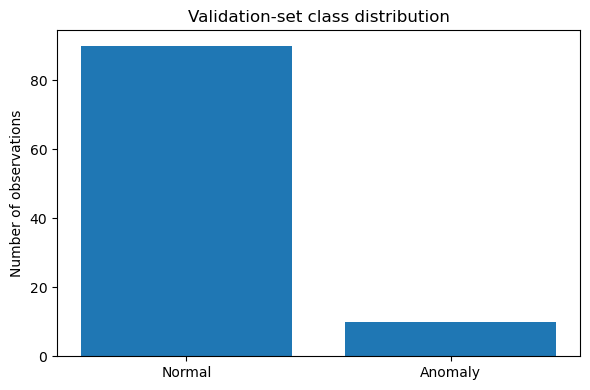

In [18]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Normal", "Anomaly"],
    [np.sum(y_val == 0), np.sum(y_val == 1)]
)

plt.ylabel("Number of observations")
plt.title("Validation-set class distribution")
plt.tight_layout()

the validation set is not simply another sample of the normal training distribution.

It contains known anomalous observations and is therefore appropriate for evaluating candidate detectors and selecting operating parameter

## Where are the anomalies

This is particularly valuable given the implicit temporal ordering

This tells you whether anomalies are:

isolated
clustered
occurring in bursts

That's directly relevant to your windowing decision.

For example, if anomalies cluster around neighboring observations, a window can potentially capture contextual information that a point-wise detector cannot.

In [19]:
anomaly_indices = np.where(y_val == 1)[0]

print(anomaly_indices)

[ 0  3 19 27 38 59 71 88 91 92]


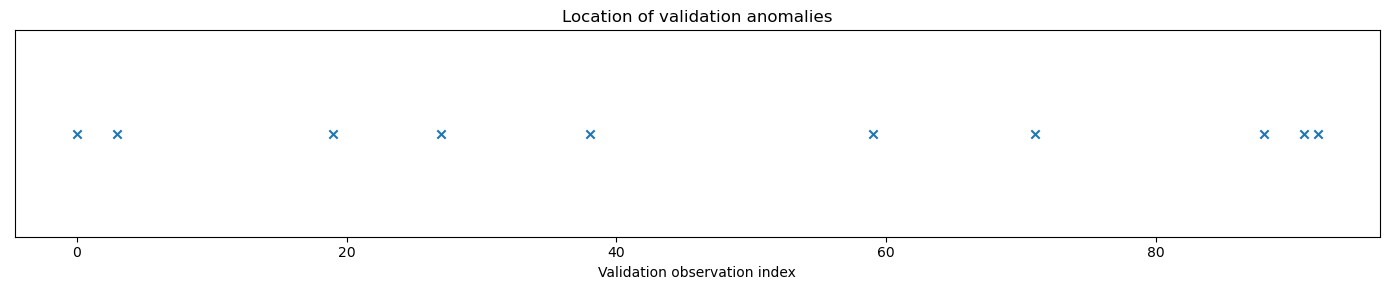

In [20]:
plt.figure(figsize=(14, 3))

plt.scatter(
    anomaly_indices,
    np.ones(len(anomaly_indices)),
    marker="x"
)

plt.yticks([])
plt.xlabel("Validation observation index")
plt.title("Location of validation anomalies")
plt.tight_layout()

## Compare normal vs anomalous feature distributions

This is probably the most valuable supervised EDA

This gives you a very useful visual answer:

Which server variables appear to change when an anomaly occurs?

You can supplement that with a standardized mean difference or simple summary table, but I wouldn't go much furthe

In [21]:
val_df = pd.DataFrame(X_val, columns=feature_names)
val_df["label"] = y_val

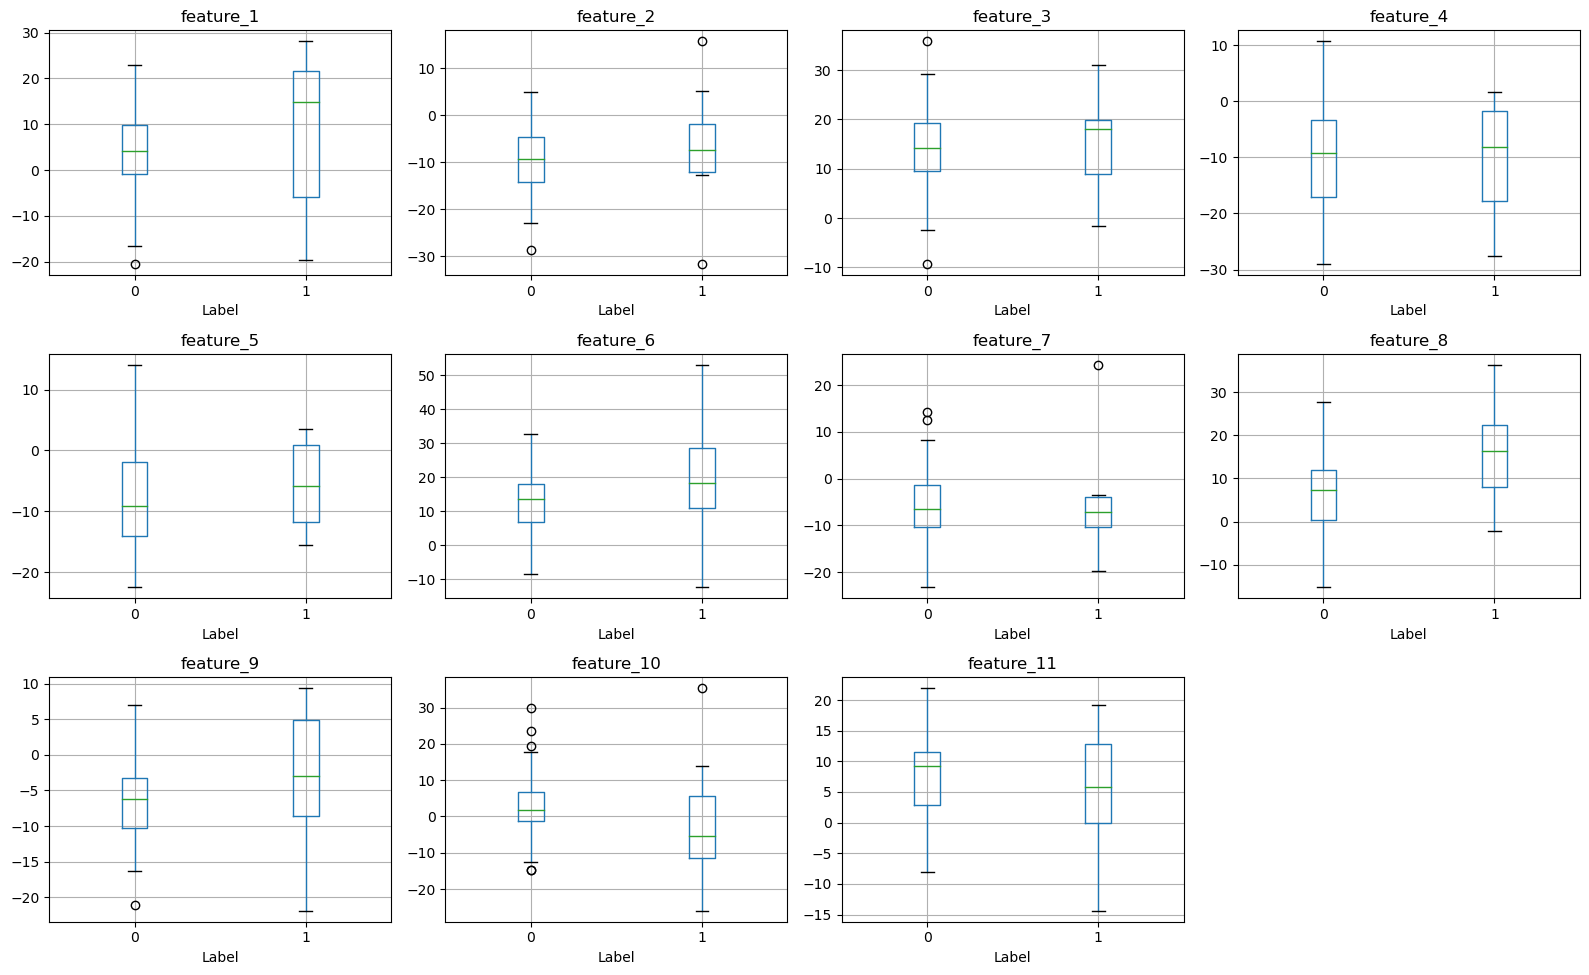

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, feature in zip(axes.flat, feature_names):
    val_df.boxplot(
        column=feature,
        by="label",
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("Label")

for ax in axes.flat[len(feature_names):]:
    ax.remove()

plt.suptitle("")
plt.tight_layout()

## Anomalies over the feature space

Don't make the conclusion:

"PCA separates anomalies, therefore PCA should be used."

Instead:

PCA provides a low-dimensional visualization of the feature space. Some separation between normal and anomalous observations may be visible, although this visualization alone is insufficient to determine whether PCA improves anomaly detection.


Since there are only 11 dimensions, PCA is useful as visualization, even if PCA is also an optional model preprocessing step.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_val_scaled = StandardScaler().fit_transform(X_val)

pca = PCA(n_components=2)
X_val_pca = pca.fit_transform(X_val_scaled)

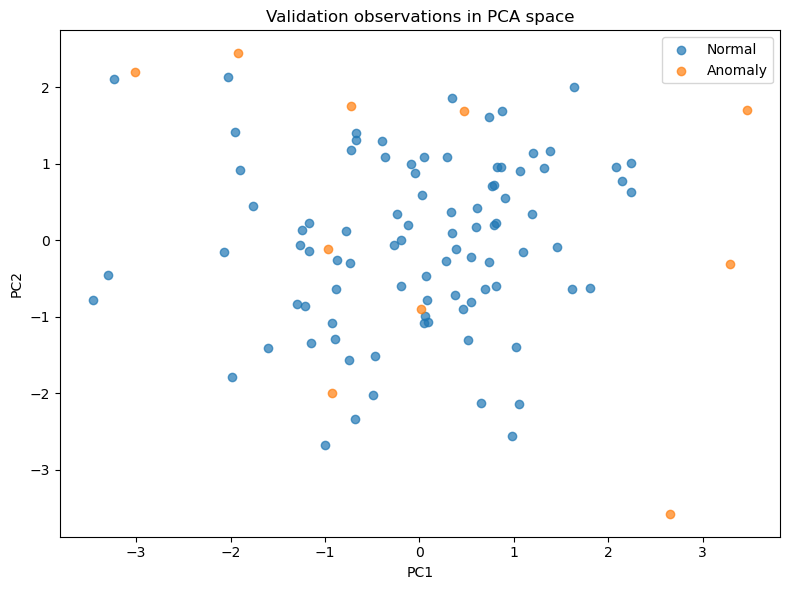

In [24]:
plt.figure(figsize=(8, 6))

for label, name in [(0, "Normal"), (1, "Anomaly")]:
    mask = y_val == label
    plt.scatter(
        X_val_pca[mask, 0],
        X_val_pca[mask, 1],
        label=name,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Validation observations in PCA space")
plt.legend()
plt.tight_layout()

## FIRST SUMMARY
Data characteristics
11 numerical server measurements.
Training data consists primarily of normal observations and is therefore used to characterize normal behavior.
Validation and test sets contain labeled anomalies.
The observations have an implicit sequential ordering, although explicit timestamps are unavailable.
Features may differ in scale and distribution, motivating configurable preprocessing.
Correlation between some variables indicates potentially shared information.
Validation anomalies can be isolated or temporally clustered, making local context potentially useful.


| Observation                               | Modeling implication                               |
| ----------------------------------------- | -------------------------------------------------- |
| Different feature scales                  | Configurable feature scaling                       |
| Feature correlation                       | PCA/SVD can be evaluated as optional preprocessing |
| Mostly normal training data               | Unsupervised/semi-supervised anomaly detection     |
| Labeled validation anomalies              | Model/threshold selection                          |
| Held-out labeled test set                 | Final unbiased evaluation                          |
| Sequential observation order              | Window-based modeling can be evaluated             |
| Potential temporal dependence             | AE/IsoForest vs sequence-aware models              |
| Only 11 features / 1,000 training samples | Keep architectures relatively small                |




## THRESHOLD EXPLORATION

Right now you have X_val and y_val, but not anomaly scores. A threshold only makes sense once a detector produces scores:

X_val → model → anomaly scores → threshold → predictions

So the EDA itself cannot tell you whether quantile=0.99 will work well before a model has produced scores.

However, you can use the validation labels to understand what threshold behavior you might want once scores exist

# widnowing

In the EDA, I'd include a small subsection like "Sequential structure and windowing" covering:

The rows have an implicit sequential/temporal order, even without explicit timestamps.
A window of size w groups consecutive observations to provide local temporal context.
window_size=1 corresponds to point-wise detection; larger windows allow models to capture short-term context.
Your project uses overlapping windows with stride 1.
For labeled validation data, a window is labeled anomalous if any observation inside it is anomalous.
Therefore, one anomalous point can generate multiple anomalous windows; consequently, window-level class counts differ from the original point-level counts.
This motivates evaluating window-based models using window-level scores and labels.

I would not put the full implementation/code in the EDA. The detailed rationale belongs in your architecture/design documentation.

So the EDA establishes:

Why temporal windows are relevant and what their basic consequences are.

Then the architecture/modeling documentation explains:

How windowing is implemented and why size=5, stride=1 was chosen


In [33]:
def transform_with_labels(X, y, seq_len=5, stride=1):
        X = np.asarray(X)
        y = np.asarray(y)



        X_windows = []
        y_windows = []

        for i in range(
            0,
            len(X) - seq_len + 1,
            stride,
        ):
            X_windows.append(
                X[i:i + seq_len]
            )

            # Window is anomalous if any point is anomalous
            y_windows.append(
                int(np.any(y[i:i + seq_len] == 1))
            )

        return (
            np.stack(X_windows),
            np.asarray(y_windows),
        )

In [34]:
X_val, y_val

(array([[ 18.27128267, -12.35926827,   5.00096952, ...,  -9.47667866,
         -25.92818273,   7.10862793],
        [ -3.19306995, -19.70582077,   6.52855559, ..., -10.96830111,
          -1.1986661 ,   1.90844104],
        [ -5.25667809, -12.9187198 ,  25.43514141, ...,  -0.76875452,
          -3.26109447,  13.72947446],
        ...,
        [ -5.19464242, -17.11659922,   3.52625883, ..., -10.5915166 ,
           2.00768975,   0.72448692],
        [  8.41538881, -11.17291978,  35.80284538, ...,  -0.41369815,
           4.07893619,  16.03930257],
        [ 16.34753553,   0.74515961,  26.12255377, ..., -12.02548694,
          -5.24075631,  13.62505607]]),
 array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 

In [35]:
X_w, y_w = transform_with_labels(X_val, y_val)

In [38]:
X_w.shape, y_w.shape

((96, 5, 11), (96,))

In [40]:
print("Normal:", np.sum(y_val == 0))
print("Anomalous:", np.sum(y_val == 1))
print("Anomaly rate:", y_val.mean())

Normal: 90
Anomalous: 10
Anomaly rate: 0.1


In [39]:
print("Normal:", np.sum(y_w == 0))
print("Anomalous:", np.sum(y_w == 1))
print("Anomaly rate:", y_w.mean())

Normal: 58
Anomalous: 38
Anomaly rate: 0.3958333333333333


Yes — this is a substantial and important distribution change, and it is exactly the kind of thing you should document in this project rather than treating it as a minor preprocessing detail.

In [ ]:
#https://chatgpt.com/c/6aa45dc9-5728-83e9-9f5e-2182dbc8a3c3

In [25]:
print("Raw validation:")
print("  samples:", len(y_val))
print("  anomalies:", np.sum(y_val == 1))

print("\nWindowed validation:")
print("  windows:", len(y_val_w))
print("  anomalous windows:", np.sum(y_val_w == 1))
print("  normal windows:", np.sum(y_val_w == 0))

Raw validation:
  samples: 100
  anomalies: 10

Windowed validation:


NameError: name 'y_val_w' is not defined

In [ ]:
1. Raw train vs validation distribution

First establish whether the datasets differ before any transformation.

For each of the 11 features:

Train vs validation mean/median
Standard deviation
quantiles
min/max
distribution plots
optionally a simple distribution-distance metric such as KS statistic

This answers:

"Does validation already come from a different distribution?"

That's important because your validation contains anomalies, but you don't want to confuse anomaly-related differences with general distribution shift